In [2]:
# pip install gseapy

In [1]:
import pandas as pd
from gseapy.plot import gseaplot
import gseapy as gp
import numpy as np

In [55]:
dea_df = pd.read_csv("../results/de_genes_Bulk_gsea_input.csv")
dea_df = dea_df.rename(columns={"Unnamed: 0": "gene"})

In [56]:
dea_df["rank"] = -np.log10(dea_df["padj"])*dea_df["log2FoldChange"]

In [57]:
dea_df = dea_df.sort_values("rank", ascending=False).reset_index(drop=True)

In [58]:
dea_df.head()

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rank
0,BARX1,31.373488,3.739751,0.750628,4.982160,6.287838e-07,0.000767,11.649353
1,ITPR2-AS1,116.289046,3.414701,0.651252,5.243285,1.577428e-07,0.000406,11.579416
2,ENSG00000248935,16.328000,4.774405,1.049133,4.550810,5.343973e-06,0.004425,11.239185
3,PTPRT,547.900619,4.572005,1.014950,4.504659,6.647965e-06,0.004671,10.655427
4,KRTAP2-3,43.573226,4.324088,0.938843,4.605762,4.109573e-06,0.003665,10.533185


In [59]:
len(dea_df)

32272

In [60]:
ranking = dea_df[["gene", "rank"]].set_index("gene", drop=True)

In [61]:
ranking.head()

,rank
gene,
BARX1,11.649353
ITPR2-AS1,11.579416
ENSG00000248935,11.239185
PTPRT,10.655427
KRTAP2-3,10.533185


In [62]:
# ranking["gene"].to_csv("../results/GOrilla_input_bulk_dea.csv", index=False)

In [63]:
adiposite_genes = pd.read_excel("../data/emont2022s1.xlsx", sheet_name="adipocyte markers", header=1)

In [64]:
adiposite_genes = list(adiposite_genes["Unnamed: 0"])

In [65]:
adiposite_genes[:5]

['NAV2', 'AC018616.1', 'FABP4', 'MAPK10', 'ITLN1']

In [66]:
shared_genes = list(set(ranking.index)&set(adiposite_genes))

In [67]:
dea_df[dea_df["gene"].isin(shared_genes)]

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rank
26,C1QB,1067.567397,2.355935,0.583357,4.038581,0.000054,0.023091,3.855638
50,C1QA,901.652756,2.274481,0.589972,3.855236,0.000116,0.032299,3.390815
81,APBB1IP,249.326677,2.150480,0.603834,3.561375,0.000369,0.052286,2.756088
83,IRF8,1345.462125,1.926645,0.517286,3.724528,0.000196,0.038451,2.726374
88,CD96,371.870520,2.397853,0.712884,3.363595,0.000769,0.075588,2.689304
...,...,...,...,...,...,...,...,...
29142,ABHD15-AS1,2.127529,0.053951,1.076615,0.050112,0.960033,NaN,NaN
29313,SLC14A2-AS1,1.262937,0.276397,1.102890,0.250612,0.802114,NaN,NaN
30126,LINC00540,26.930634,-1.715822,0.914597,-1.876041,NaN,NaN,NaN
30219,LINC02391,5.968064,1.581716,0.789950,2.002300,0.045252,NaN,NaN


In [68]:
len(adiposite_genes)

2586

In [69]:
shared_genes = set(adiposite_genes)&set(dea_df["gene"])

In [70]:
len(shared_genes)

1702

In [71]:
pre_res = gp.prerank(
    rnk=ranking,
    gene_sets={"my_set": adiposite_genes},
    seed=2,
    # min_size=1,
    max_size=10000,
    verbose=True
)

2025-04-22 11:05:23,093 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2025-04-22 11:05:23,141 [INFO] Input gene rankings contains duplicated IDs
2025-04-22 11:05:23,145 [INFO] Parsing data files for GSEA.............................
2025-04-22 11:05:23,159 [INFO] 0000 gene_sets have been filtered out when max_size=10000 and min_size=15
2025-04-22 11:05:23,160 [INFO] 0001 gene_sets used for further statistical testing.....
2025-04-22 11:05:23,160 [INFO] Start to run GSEA...Might take a while..................
2025-04-22 11:05:23,526 [INFO] Congratulations. GSEApy runs successfully................



In [72]:
# pre_res.results

In [73]:
out = []
for term in list(pre_res.results):
    out.append(
        [
            term,
            pre_res.results[term]["fdr"],
            pre_res.results[term]["es"],
            pre_res.results[term]["nes"],
        ]
    )

out_df = pd.DataFrame(
    out,
    columns=["Term", "fdr", "es", "nes"],
).sort_values(
    "fdr",
).reset_index(
    drop=True
)

out_df

,Term,fdr,es,nes
0,my_set,0.011429,-0.5237,-1.325866


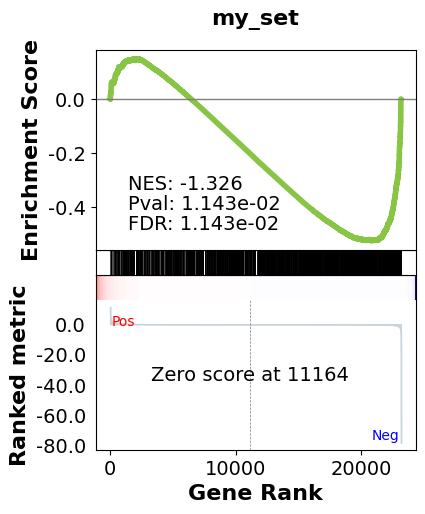

In [74]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=out_df["Term"].iloc[0])

In [75]:
figname="../results/figures/gsea_plot_bulk"
axs.savefig(figname + ".png", bbox_inches="tight")
axs.savefig(figname + ".pdf", bbox_inches="tight")